# Đánh giá Model DDPM1D_cls_free_MITBIH

Notebook này đánh giá hiệu quả của model **DDPM1D_cls_free_MITBIH** (Label Conditional Model) theo các metrics trong paper BioDiffusion.

## Model Information
- **Model Type**: Classifier-Free Guidance Diffusion Model
- **Dataset**: MIT-BIH Arrhythmia Database
- **Classes**: 5 classes (Non-Ectopic Beats, Superventrical Ectopic, Ventricular Beats, Unknown, Fusion Beats)
- **Sequence Length**: 128 timesteps

## Evaluation Metrics (theo paper)
1. **Visual Similarity**: So sánh trực quan giữa real và synthetic signals
2. **UMAP Projection**: Visualization trong không gian giảm chiều
3. **Wavelet Coherence Score**: Đánh giá tương đồng trong miền tần số
4. **Discriminative Score**: Khả năng phân biệt real vs synthetic (lower is better)
5. **F1-Score**: Đánh giá chất lượng classification của synthetic signals


In [3]:
from google.colab import drive
import os
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/biodiffusion"
os.chdir(base_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Import libraries
import os
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils import data
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from MITBIH import mitbih_allClass, reverse_cls_dit
from modules.modules1D_cls_free import Unet1D_cls_free, GaussianDiffusion1D_cls_free
from utils import save_signals_cls_free

# Evaluation metrics
try:
    import pywt
    HAS_PYWAVELETS = True
except ImportError:
    HAS_PYWAVELETS = False
    print("Warning: PyWavelets not installed. Wavelet Coherence will use alternative method.")

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("Warning: UMAP not installed. UMAP visualization will be skipped.")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
# Configuration
CHECKPOINT_PATH = "checkpoint/DDPM1D_cls_free_MITBIH/checkpoint_best.pt"
TEST_DATA_PATH = "datasets/heartbeat/mitbih_test.csv"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model hyperparameters
NUM_CLASSES = 5
SEQ_LENGTH = 128
DIM = 64
DIM_MULTS = (1, 2, 4, 8)
COND_DROP_PROB = 0.5
CHANNELS = 1

# Generation parameters
N_SAMPLES_PER_CLASS = 200  # Số lượng samples generate cho mỗi class
CFG_SCALE = 3.0  # Classifier-free guidance scale

print(f"Device: {DEVICE}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"Test data path: {TEST_DATA_PATH}")


Device: cuda
Checkpoint path: checkpoint/DDPM1D_cls_free_MITBIH/checkpoint_best.pt
Test data path: datasets/heartbeat/mitbih_test.csv


## 1. Load Model từ Checkpoint


In [6]:
def load_model(checkpoint_path, num_classes=5, seq_length=128, device='cuda',
               dim=64, dim_mults=(1, 2, 4, 8), cond_drop_prob=0.5, channels=1):
    """Load trained model from checkpoint"""
    model = Unet1D_cls_free(
        dim=dim,
        dim_mults=dim_mults,
        num_classes=num_classes,
        cond_drop_prob=cond_drop_prob,
        channels=channels
    ).to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    elif 'model' in checkpoint:
        if hasattr(checkpoint['model'], 'state_dict'):
            state_dict = checkpoint['model'].state_dict()
        else:
            state_dict = checkpoint['model']
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict, strict=False)
    model.eval()

    diffusion = GaussianDiffusion1D_cls_free(
        model,
        seq_length=seq_length,
        timesteps=1000
    ).to(device)
    diffusion.eval()

    return model, diffusion

# Load model
print("Loading model...")
model, diffusion = load_model(
    CHECKPOINT_PATH, NUM_CLASSES, SEQ_LENGTH, DEVICE,
    DIM, DIM_MULTS, COND_DROP_PROB, CHANNELS
)
print("Model loaded successfully!")


Loading model...
Model loaded successfully!


## 2. Load Test Dataset


In [7]:
class TestDataset(data.Dataset):
    """Test dataset loader"""
    def __init__(self, filename):
        self.fiveClassECG = mitbih_allClass(filename=filename, isBalanced=False)

    def __len__(self):
        return len(self.fiveClassECG)

    def __getitem__(self, idx):
        signals, labels = self.fiveClassECG[idx]
        return signals, labels

# Load test dataset
print("Loading test dataset...")
test_dataset = TestDataset(filename=TEST_DATA_PATH)
test_dataloader = data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
print(f"Test dataset loaded: {len(test_dataset)} samples")

# Collect real signals and labels
real_signals_list = []
real_labels_list = []

print("Collecting real signals from test set...")
for signals, labels in tqdm(test_dataloader, desc="Loading test data"):
    if isinstance(signals, np.ndarray):
        signals = torch.from_numpy(signals).float()
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels).long()

    signals = signals.to(DEVICE)
    real_signals_list.append(signals.cpu().numpy())
    real_labels_list.append(labels.cpu().numpy())

real_signals = np.concatenate(real_signals_list, axis=0)
real_labels = np.concatenate(real_labels_list, axis=0).astype(np.int64)

print(f"Real signals shape: {real_signals.shape}")
print(f"Real labels distribution: {np.bincount(real_labels)}")


Loading test dataset...
X_train shape is (21892, 1, 128)
y_train shape is (21892,)
The dataset including 18118 class 0, 556 class 1, 1448 class 2, 162 class 3, 1608 class 4
Test dataset loaded: 21892 samples


Loading test data: 100%|██████████| 685/685 [00:00<00:00, 2958.39it/s]

Real signals shape: (21892, 1, 128)
Real labels distribution: [18118   556  1448   162  1608]


## 3. Generate Synthetic Signals


In [8]:
# Generate signals for each class
print(f"Generating {N_SAMPLES_PER_CLASS} samples per class...")
generated_signals_list = []
generated_labels_list = []

for class_id in range(NUM_CLASSES):
    labels = torch.tensor([class_id] * N_SAMPLES_PER_CLASS, device=DEVICE)

    with torch.no_grad():
        gen_signals = diffusion.sample(classes=labels, cond_scale=CFG_SCALE)

    generated_signals_list.append(gen_signals.cpu().numpy())
    generated_labels_list.append([class_id] * N_SAMPLES_PER_CLASS)
    print(f"Generated {N_SAMPLES_PER_CLASS} samples for class {class_id} ({reverse_cls_dit[class_id]})")

generated_signals = np.concatenate(generated_signals_list, axis=0)
generated_labels = np.array(generated_labels_list).flatten().astype(np.int64)

print(f"Generated signals shape: {generated_signals.shape}")


Generating 200 samples per class...


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 200 samples for class 0 (Non-Ectopic Beats)


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 200 samples for class 1 (Superventrical Ectopic)


...

Generated 200 samples for class 2 (Ventricular Beats)


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 200 samples for class 3 (Unknown)


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Generated 200 samples for class 4 (Fusion Beats)
Generated signals shape: (1000, 1, 128)


## 4. Visual Comparison - Sample Signals


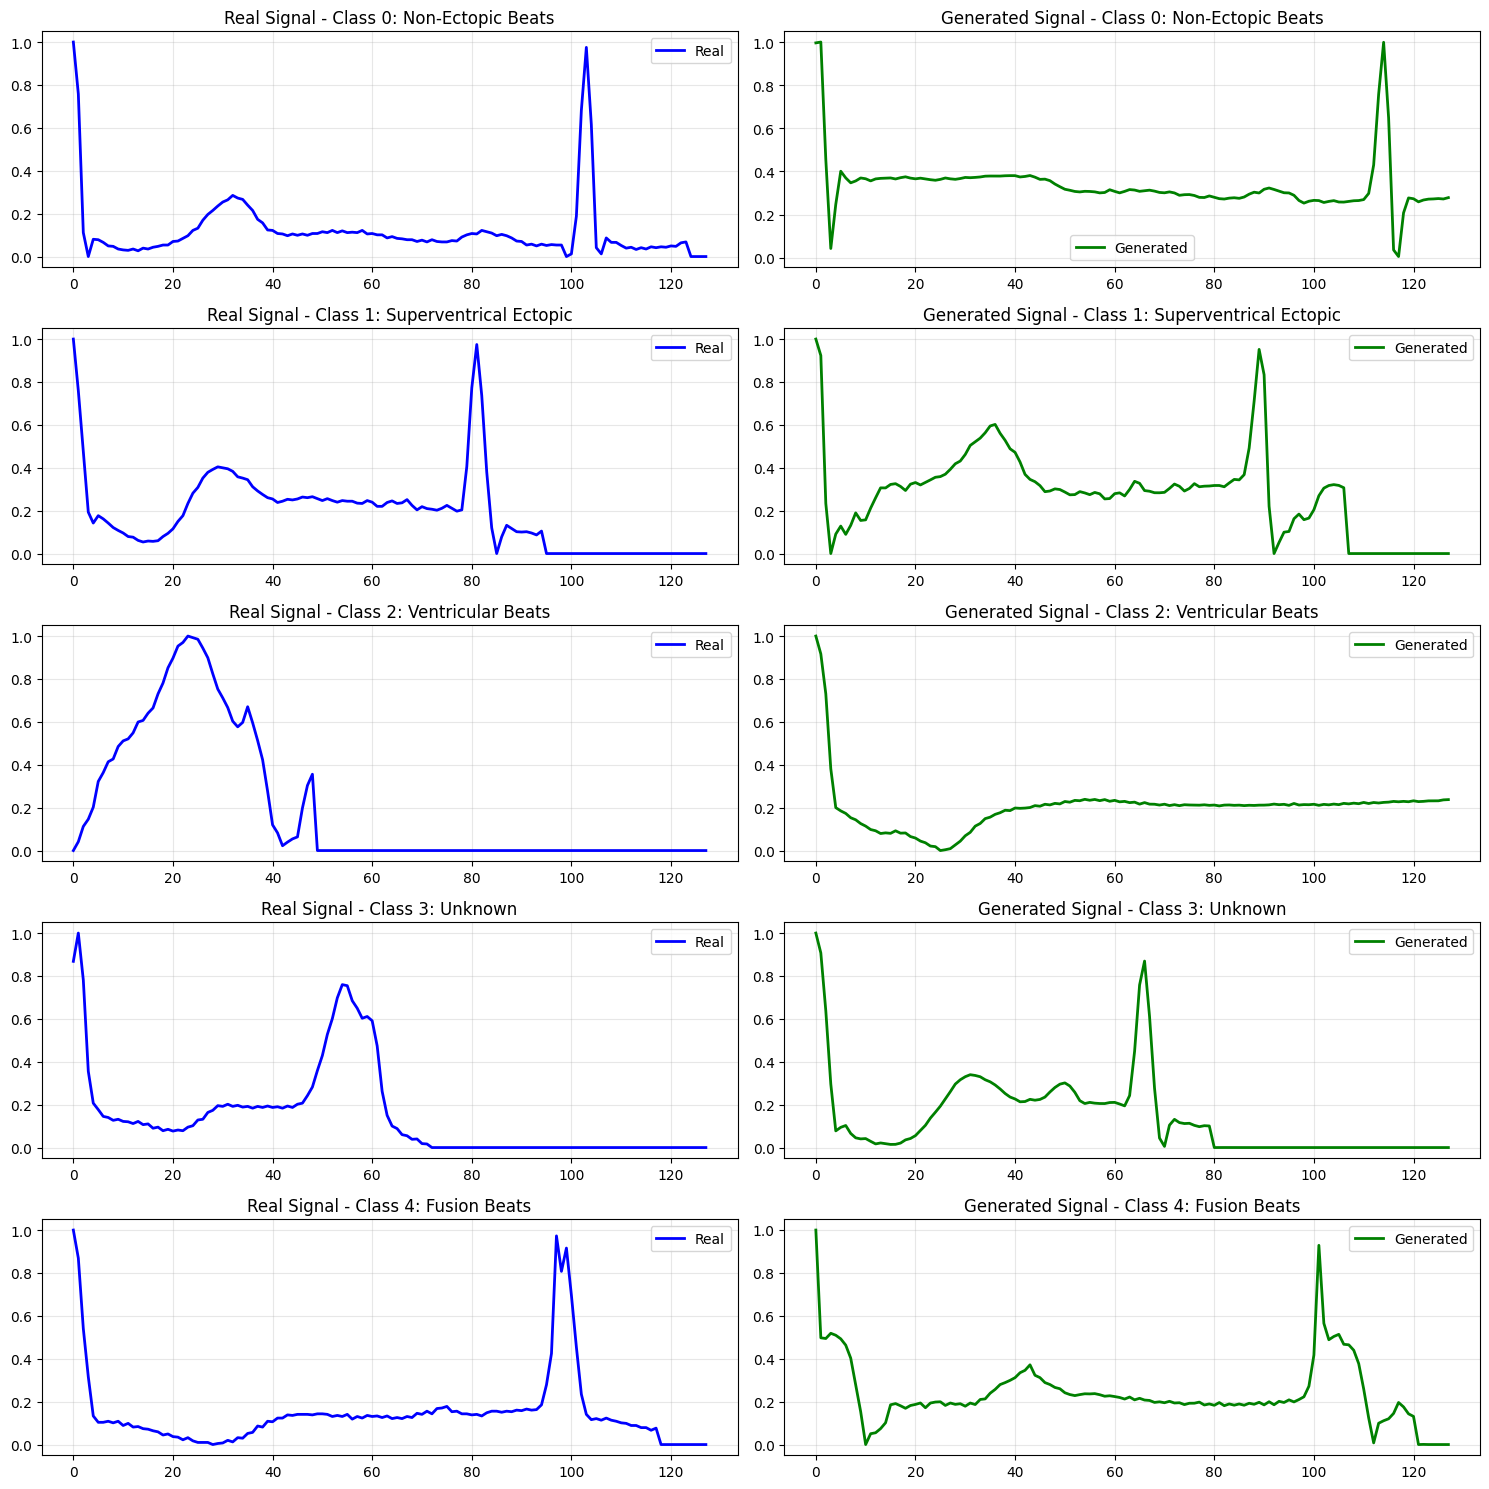

In [9]:
# Visualize samples from each class
fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(15, 3*NUM_CLASSES))

for class_id in range(NUM_CLASSES):
    # Get one real sample
    real_idx = np.where(real_labels == class_id)[0][0]
    real_sig = real_signals[real_idx, 0, :]

    # Get one generated sample
    gen_idx = np.where(generated_labels == class_id)[0][0]
    gen_sig = generated_signals[gen_idx, 0, :]

    # Plot
    axes[class_id, 0].plot(real_sig, label='Real', color='blue', linewidth=2)
    axes[class_id, 0].set_title(f"Real Signal - Class {class_id}: {reverse_cls_dit[class_id]}")
    axes[class_id, 0].grid(True, alpha=0.3)
    axes[class_id, 0].legend()

    axes[class_id, 1].plot(gen_sig, label='Generated', color='green', linewidth=2)
    axes[class_id, 1].set_title(f"Generated Signal - Class {class_id}: {reverse_cls_dit[class_id]}")
    axes[class_id, 1].grid(True, alpha=0.3)
    axes[class_id, 1].legend()

plt.tight_layout()
os.makedirs("results/DDPM1D_cls_free_MITBIH", exist_ok=True)
plt.savefig("results/DDPM1D_cls_free_MITBIH/visual_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


## 5. Evaluation Metrics


In [13]:
def wavelet_coherence_score(real_signals, generated_signals, wavelet='db4', max_level=None):
    """
    Calculate Wavelet Coherence Score between real and generated signals.
    Uses Discrete Wavelet Transform (DWT) instead of CWT for better compatibility.
    """
    coherence_scores = []
    n_samples = min(len(real_signals), len(generated_signals))

    for i in tqdm(range(n_samples), desc="Computing wavelet coherence"):
        real_sig = real_signals[i, 0, :] if real_signals.ndim == 3 else real_signals[i, :]
        gen_sig = generated_signals[i, 0, :] if generated_signals.ndim == 3 else generated_signals[i, :]

        # Normalize signals
        real_sig = (real_sig - real_sig.mean()) / (real_sig.std() + 1e-8)
        gen_sig = (gen_sig - gen_sig.mean()) / (gen_sig.std() + 1e-8)

        try:
            if HAS_PYWAVELETS:
                # Determine maximum decomposition level
                if max_level is None:
                    max_level = pywt.dwt_max_level(len(real_sig), wavelet)
                    max_level = min(max_level, 5)  # Limit to 5 levels for stability

                # Perform Discrete Wavelet Transform
                # wavedec returns [cA_n, cD_n, cD_n-1, ..., cD_1] where cA is approximation, cD are details
                coeffs_real = pywt.wavedec(real_sig, wavelet, level=max_level)
                coeffs_gen = pywt.wavedec(gen_sig, wavelet, level=max_level)

                # Calculate coherence for each coefficient level
                level_coherences = []
                for idx in range(len(coeffs_real)):
                    c_real = coeffs_real[idx]
                    c_gen = coeffs_gen[idx]

                    # Ensure same length (should be same after DWT, but check anyway)
                    min_len = min(len(c_real), len(c_gen))
                    if min_len > 0:
                        c_real = c_real[:min_len]
                        c_gen = c_gen[:min_len]

                        # Calculate Pearson correlation coefficient
                        c_real_norm = (c_real - c_real.mean()) / (c_real.std() + 1e-8)
                        c_gen_norm = (c_gen - c_gen.mean()) / (c_gen.std() + 1e-8)
                        correlation = np.mean(c_real_norm * c_gen_norm)
                        coherence = np.abs(correlation)  # Use absolute value
                        level_coherences.append(coherence)

                # Weighted average: higher weights for approximation coefficients (first element)
                # and lower frequency detail coefficients
                if len(level_coherences) > 0:
                    # Approximation gets highest weight, then details in reverse order
                    weights = np.array([2**(len(level_coherences) - idx - 1) for idx in range(len(level_coherences))])
                    weights = weights / weights.sum()
                    avg_coherence = np.average(level_coherences, weights=weights)
                else:
                    avg_coherence = 0.0
            else:
                # FFT-based coherence as fallback
                fft_real = np.fft.fft(real_sig)
                fft_gen = np.fft.fft(gen_sig)

                cross_spectrum = np.abs(fft_real * np.conj(fft_gen))
                power_real = np.abs(fft_real) ** 2
                power_gen = np.abs(fft_gen) ** 2

                coherence = cross_spectrum / (np.sqrt(power_real * power_gen) + 1e-8)
                avg_coherence = np.mean(coherence)

            coherence_scores.append(avg_coherence)
        except Exception as e:
            # Fallback to FFT-based coherence if DWT fails
            try:
                fft_real = np.fft.fft(real_sig)
                fft_gen = np.fft.fft(gen_sig)

                cross_spectrum = np.abs(fft_real * np.conj(fft_gen))
                power_real = np.abs(fft_real) ** 2
                power_gen = np.abs(fft_gen) ** 2

                coherence = cross_spectrum / (np.sqrt(power_real * power_gen) + 1e-8)
                avg_coherence = np.mean(coherence)
                coherence_scores.append(avg_coherence)
            except:
                coherence_scores.append(0.0)

    return np.mean(coherence_scores) if len(coherence_scores) > 0 else 0.0

def discriminative_score(real_signals, generated_signals):
    """Calculate Discriminative Score using a classifier. Lower score = better."""
    n_real = len(real_signals)
    n_gen = len(generated_signals)

    all_signals = np.concatenate([real_signals, generated_signals], axis=0)
    labels = np.concatenate([np.zeros(n_real), np.ones(n_gen)])

    if all_signals.ndim == 3:
        all_signals_flat = all_signals.reshape(all_signals.shape[0], -1)
    else:
        all_signals_flat = all_signals

    # Extract statistical features
    features = []
    for sig in all_signals_flat:
        features.append([
            np.mean(sig), np.std(sig), np.var(sig), np.min(sig), np.max(sig),
            np.median(sig), np.percentile(sig, 25), np.percentile(sig, 75),
            np.sum(np.abs(np.diff(sig))),
        ])

    features = np.array(features)

    # Train classifier
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42, stratify=labels
    )

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    return 1.0 - accuracy  # Lower is better

def f1_score_metric(real_signals, generated_signals, real_labels, generated_labels):
    """Calculate F1-Score for classification task."""
    if real_signals.ndim == 3:
        real_flat = real_signals.reshape(real_signals.shape[0], -1)
        gen_flat = generated_signals.reshape(generated_signals.shape[0], -1)
    else:
        real_flat = real_signals
        gen_flat = generated_signals

    # Train classifier on real data
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(real_flat, real_labels)

    # Predict on generated signals
    gen_pred = clf.predict(gen_flat)

    f1_macro = f1_score(generated_labels, gen_pred, average='macro')
    f1_weighted = f1_score(generated_labels, gen_pred, average='weighted')
    f1_per_class = f1_score(generated_labels, gen_pred, average=None)

    return {
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_per_class': f1_per_class,
        'predictions': gen_pred
    }

# Match number of samples
n_samples = min(len(real_signals), len(generated_signals))
real_signals_eval = real_signals[:n_samples]
real_labels_eval = real_labels[:n_samples]
generated_signals_eval = generated_signals[:n_samples]
generated_labels_eval = generated_labels[:n_samples]

print("\n" + "="*60)
print("Calculating Evaluation Metrics")
print("="*60)

# 1. Wavelet Coherence Score
print("\n1. Calculating Wavelet Coherence Score...")
coherence_score = wavelet_coherence_score(real_signals_eval, generated_signals_eval)
print(f"   Wavelet Coherence Score: {coherence_score:.6f}")

# 2. Discriminative Score
print("\n2. Calculating Discriminative Score...")
disc_score = discriminative_score(real_signals_eval, generated_signals_eval)
print(f"   Discriminative Score: {disc_score:.6f} (lower is better)")

# 3. F1-Score
print("\n3. Calculating F1-Score...")
f1_results = f1_score_metric(real_signals_eval, generated_signals_eval, real_labels_eval, generated_labels_eval)
print(f"   F1-Score (Macro): {f1_results['f1_macro']:.6f}")
print(f"   F1-Score (Weighted): {f1_results['f1_weighted']:.6f}")
print("\n   F1-Score per class:")
for i, f1 in enumerate(f1_results['f1_per_class']):
    print(f"     Class {i} ({reverse_cls_dit[i]}): {f1:.6f}")



Calculating Evaluation Metrics

1. Calculating Wavelet Coherence Score...


Computing wavelet coherence: 100%|██████████| 1000/1000 [00:01<00:00, 651.32it/s]


   Wavelet Coherence Score: 0.553554

2. Calculating Discriminative Score...
   Discriminative Score: 0.107500 (lower is better)

3. Calculating F1-Score...
   F1-Score (Macro): 0.066667
   F1-Score (Weighted): 0.066667

   F1-Score per class:
     Class 0 (Non-Ectopic Beats): 0.333333
     Class 1 (Superventrical Ectopic): 0.000000
     Class 2 (Ventricular Beats): 0.000000
     Class 3 (Unknown): 0.000000
     Class 4 (Fusion Beats): 0.000000


Fitting UMAP...


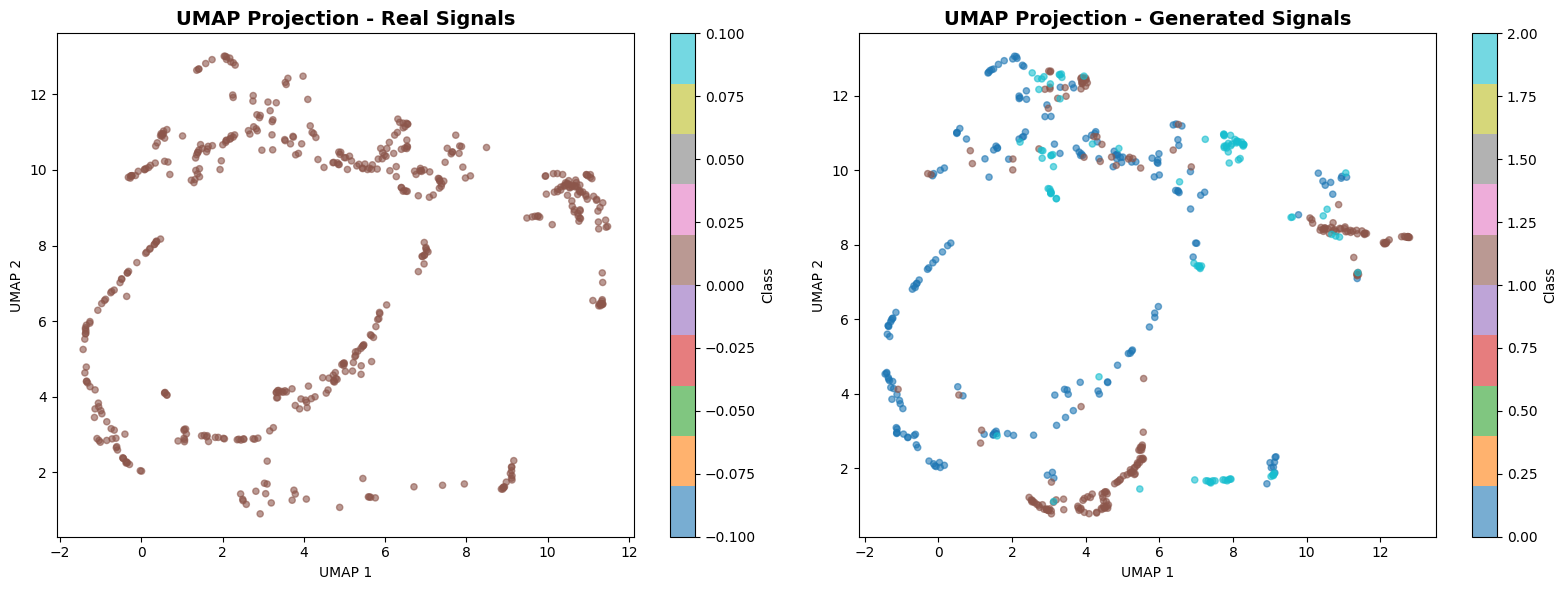

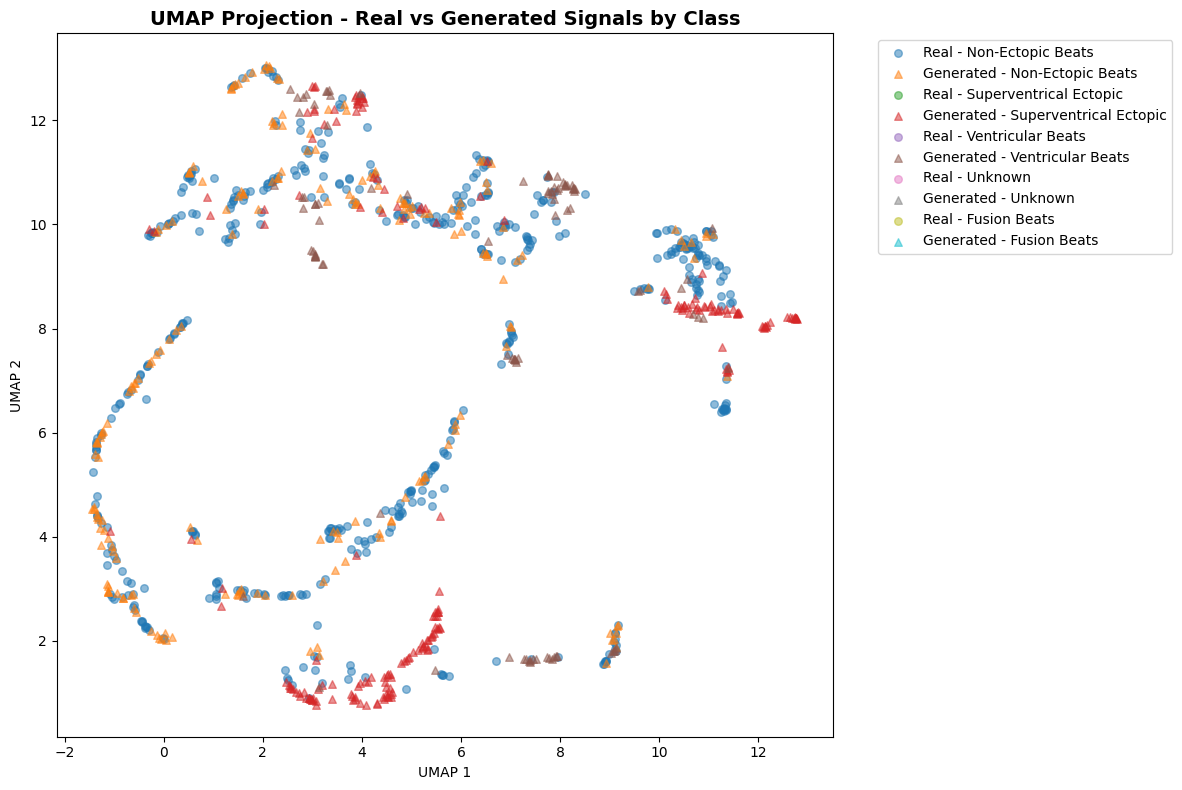

In [11]:
if HAS_UMAP:
    # Prepare data for UMAP
    n_vis = min(500, len(real_signals), len(generated_signals))  # Limit for visualization

    real_vis = real_signals[:n_vis]
    gen_vis = generated_signals[:n_vis]
    real_labels_vis = real_labels[:n_vis]
    gen_labels_vis = generated_labels[:n_vis]

    # Flatten signals
    if real_vis.ndim == 3:
        real_flat = real_vis.reshape(real_vis.shape[0], -1)
        gen_flat = gen_vis.reshape(gen_vis.shape[0], -1)
    else:
        real_flat = real_vis
        gen_flat = gen_vis

    # Combine and fit UMAP
    all_data = np.vstack([real_flat, gen_flat])

    print("Fitting UMAP...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    embedding = reducer.fit_transform(all_data)

    real_embedding = embedding[:n_vis]
    gen_embedding = embedding[n_vis:]

    # Plot UMAP
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Real signals colored by class
    scatter1 = axes[0].scatter(real_embedding[:, 0], real_embedding[:, 1],
                             c=real_labels_vis, cmap='tab10', alpha=0.6, s=20)
    axes[0].set_title('UMAP Projection - Real Signals', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('UMAP 1')
    axes[0].set_ylabel('UMAP 2')
    plt.colorbar(scatter1, ax=axes[0], label='Class')

    # Plot 2: Generated signals colored by class
    scatter2 = axes[1].scatter(gen_embedding[:, 0], gen_embedding[:, 1],
                              c=gen_labels_vis, cmap='tab10', alpha=0.6, s=20)
    axes[1].set_title('UMAP Projection - Generated Signals', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    plt.colorbar(scatter2, ax=axes[1], label='Class')

    plt.tight_layout()
    plt.savefig("results/DDPM1D_cls_free_MITBIH/umap_projection.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Combined plot
    plt.figure(figsize=(12, 8))
    for class_id in range(NUM_CLASSES):
        real_mask = real_labels_vis == class_id
        gen_mask = gen_labels_vis == class_id

        plt.scatter(real_embedding[real_mask, 0], real_embedding[real_mask, 1],
                   label=f'Real - {reverse_cls_dit[class_id]}', alpha=0.5, s=30, marker='o')
        plt.scatter(gen_embedding[gen_mask, 0], gen_embedding[gen_mask, 1],
                   label=f'Generated - {reverse_cls_dit[class_id]}', alpha=0.5, s=30, marker='^')

    plt.title('UMAP Projection - Real vs Generated Signals by Class', fontsize=14, fontweight='bold')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig("results/DDPM1D_cls_free_MITBIH/umap_combined.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("UMAP not available. Skipping UMAP visualization.")


## 7. Summary và Lưu Kết Quả


In [14]:
# Create results directory
results_dir = Path("results/DDPM1D_cls_free_MITBIH")
results_dir.mkdir(parents=True, exist_ok=True)

# Save results
results = {
    'wavelet_coherence': coherence_score,
    'discriminative_score': disc_score,
    'f1_macro': f1_results['f1_macro'],
    'f1_weighted': f1_results['f1_weighted'],
    'f1_per_class': f1_results['f1_per_class'].tolist(),
    'n_samples': n_samples,
    'n_samples_per_class': N_SAMPLES_PER_CLASS,
    'cfg_scale': CFG_SCALE
}

# Save to text file
results_path = results_dir / "evaluation_results.txt"
with open(results_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("Model Evaluation Results - DDPM1D_cls_free_MITBIH\n")
    f.write("="*60 + "\n\n")
    f.write(f"Checkpoint: {CHECKPOINT_PATH}\n")
    f.write(f"Test Dataset: {TEST_DATA_PATH}\n")
    f.write(f"Number of samples: {n_samples}\n")
    f.write(f"Samples per class: {N_SAMPLES_PER_CLASS}\n")
    f.write(f"CFG Scale: {CFG_SCALE}\n\n")
    f.write("Metrics:\n")
    f.write(f"  Wavelet Coherence Score: {coherence_score:.6f}\n")
    f.write(f"  Discriminative Score: {disc_score:.6f} (lower is better)\n")
    f.write(f"  F1-Score (Macro): {f1_results['f1_macro']:.6f}\n")
    f.write(f"  F1-Score (Weighted): {f1_results['f1_weighted']:.6f}\n")
    f.write("\nF1-Score per class:\n")
    for i, f1 in enumerate(f1_results['f1_per_class']):
        f.write(f"  Class {i} ({reverse_cls_dit[i]}): {f1:.6f}\n")

print(f"\nResults saved to: {results_path}")

# Print summary
print("\n" + "="*60)
print("EVALUATION SUMMARY")
print("="*60)
print(f"Wavelet Coherence Score: {coherence_score:.6f}")
print(f"Discriminative Score: {disc_score:.6f} (lower is better)")
print(f"F1-Score (Macro): {f1_results['f1_macro']:.6f}")
print(f"F1-Score (Weighted): {f1_results['f1_weighted']:.6f}")
print("="*60)



Results saved to: results/DDPM1D_cls_free_MITBIH/evaluation_results.txt

EVALUATION SUMMARY
Wavelet Coherence Score: 0.553554
Discriminative Score: 0.107500 (lower is better)
F1-Score (Macro): 0.066667
F1-Score (Weighted): 0.066667
